# Sections 6 & 7 — Classification (Decision Tree, KNN, Naive Bayes)
**Course:** Data Mining
**Project:** FitZone Sports
**References:** `Section+6_Data+Mining_Classification.pdf`,
`Section+7_+Classification_part+2.pdf`, `knn+naive+bayes+confusion.pdf`

> Eng. Taher's task (التاسك رقم ٤): *Select a dataset from Kaggle to build
> three classification models. Implement Decision Tree, KNN, and Naive Bayes.
> Assess each model using a Confusion Matrix, Accuracy, Precision and Recall.*

We use the **Wine** dataset (built into scikit-learn — no Kaggle download
required). It has 178 samples, 13 numeric features, and 3 classes
(cultivar 0/1/2). To swap in any Kaggle CSV, change `pd.read_csv` in the
loading cell and update the `target` variable.

The notebook also contains the **hand-solved confusion-matrix** Task 1 from
`knn+naive+bayes+confusion.pdf` (the small 9-row actual / predicted table).

## 1. Imports

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets        import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
np.random.seed(42)

## 2. Load + clean

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.rename(columns=lambda c: c.replace(' ', '_').lower())
df['target'] = df['target'].map(dict(enumerate(wine.target_names)))

target = 'target'
print(df.shape)
df.head()

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
# Quick EDA
print(df[target].value_counts())
print("missing:", df.isnull().sum().sum())
df.describe()

target
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64
missing: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## 3. Train / test split + feature scaling

In [4]:
X = df.drop(target, axis=1)
y = df[target]

# Encode any string columns in X (none for Wine but safe template)
for c in X.select_dtypes(include='object').columns:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_te_s  = scaler.transform(X_te)

print('train:', X_tr.shape, '  test:', X_te.shape)

train: (124, 13)   test: (54, 13)


## 4. Train the three classifiers


=== Decision Tree ===
confusion matrix (rows = actual, cols = predicted):
         class_0  class_1  class_2
class_0       16        2        0
class_1        1       18        2
class_2        0        0       15
              precision    recall  f1-score   support

     class_0       0.94      0.89      0.91        18
     class_1       0.90      0.86      0.88        21
     class_2       0.88      1.00      0.94        15

    accuracy                           0.91        54
   macro avg       0.91      0.92      0.91        54
weighted avg       0.91      0.91      0.91        54



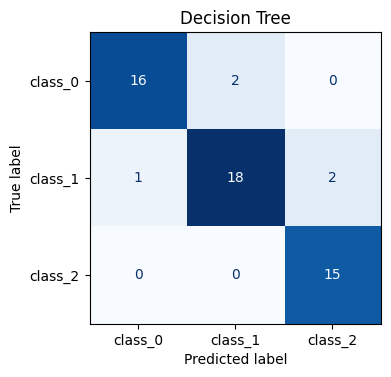


=== KNN (k=5) ===
confusion matrix (rows = actual, cols = predicted):
         class_0  class_1  class_2
class_0       18        0        0
class_1        0       18        3
class_2        0        0       15
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.86      0.92        21
     class_2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54



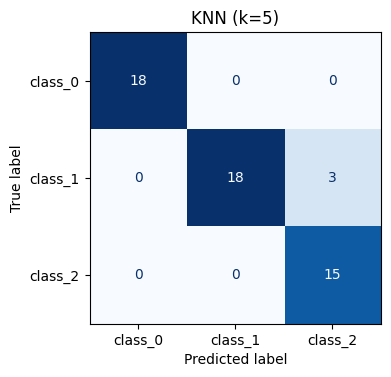


=== Naive Bayes ===
confusion matrix (rows = actual, cols = predicted):
         class_0  class_1  class_2
class_0       18        0        0
class_1        0       21        0
class_2        0        0       15
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



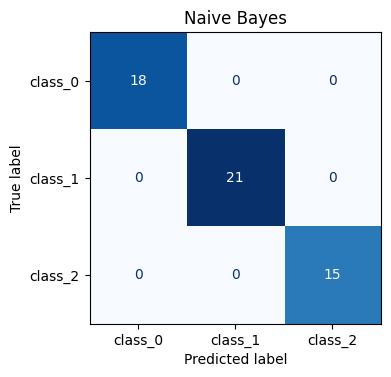

In [5]:
models = {
    'Decision Tree': (DecisionTreeClassifier(criterion='entropy', random_state=42),
                      X_tr,   X_te),
    'KNN (k=5)'    : (KNeighborsClassifier(n_neighbors=5),
                      X_tr_s, X_te_s),
    'Naive Bayes'  : (GaussianNB(),
                      X_tr,   X_te),
}

results = []
for name, (clf, Xtr, Xte) in models.items():
    clf.fit(Xtr, y_tr)
    y_pred = clf.predict(Xte)
    avg = 'binary' if y.nunique() == 2 else 'macro'
    acc  = accuracy_score(y_te,  y_pred)
    prec = precision_score(y_te, y_pred, average=avg)
    rec  = recall_score(y_te,    y_pred, average=avg)
    f1   = f1_score(y_te,        y_pred, average=avg)
    cm   = confusion_matrix(y_te, y_pred, labels=clf.classes_)

    print(f"\n=== {name} ===")
    print('confusion matrix (rows = actual, cols = predicted):')
    print(pd.DataFrame(cm, index=clf.classes_, columns=clf.classes_))
    print(classification_report(y_te, y_pred))

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name); plt.tight_layout(); plt.show()

    results.append({'model': name, 'accuracy': acc,
                    'precision': prec, 'recall': rec, 'f1': f1})

## 5. Compare the models

In [6]:
res = pd.DataFrame(results).set_index('model').round(3)
res

,accuracy,precision,recall,f1
model,,,,
Decision Tree,0.907,0.908,0.915,0.910
KNN (k=5),0.944,0.944,0.952,0.944
Naive Bayes,1.000,1.000,1.000,1.000


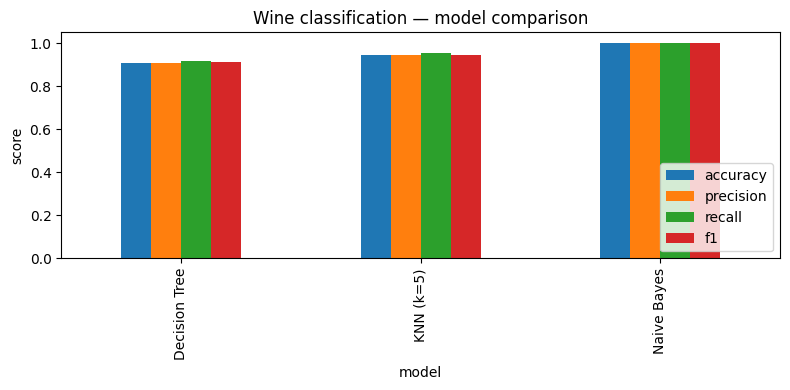

In [7]:
ax = res.plot(kind='bar', figsize=(8, 4), ylim=(0, 1.05))
ax.set_title('Wine classification — model comparison')
ax.set_ylabel('score'); ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 6. Visualise the Decision Tree

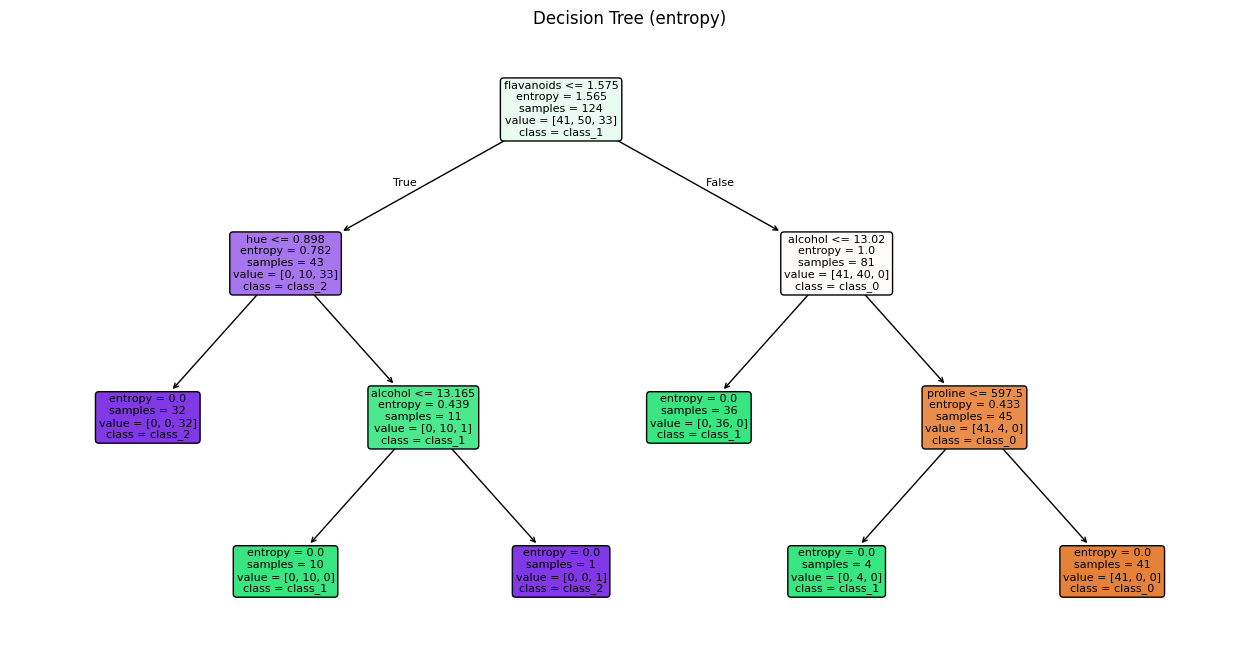

In [8]:
dt = models['Decision Tree'][0]
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=X.columns, class_names=dt.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (entropy)'); plt.show()

## 7. Hand-solved confusion matrix
*(Task 1 from `knn+naive+bayes+confusion.pdf`)*

Given the table below (rows in the order shown in the PDF):

| actual | predicted |
|:------:|:---------:|
|   1    |    1      |
|   1    |    0      |
|   0    |    0      |
|   1    |    1      |
|   0    |    0      |
|   0    |    0      |
|   1    |    1      |
|   0    |    1      |
|   0    |    1      |
|   0    |    0      |

Counting:

- **TP** = actual 1, predicted 1 → 3
- **TN** = actual 0, predicted 0 → 4
- **FP** = actual 0, predicted 1 → 2
- **FN** = actual 1, predicted 0 → 1

Then:

- P (positives) = TP + FN = 4
- N (negatives) = TN + FP = 6
- **Accuracy**  = (TP + TN) / (TP + TN + FP + FN) = (3 + 4) / 10 = **0.70**
- **Recall**    = TP / (TP + FN) = 3 / 4 = **0.75**
- **Precision** = TP / (TP + FP) = 3 / 5 = **0.60**
- **F1**        = 2 · P · R / (P + R) = 2 · 0.60 · 0.75 / (0.60 + 0.75) = **0.6667**

The cell below verifies these by computing the same matrix in Python.

In [9]:
actual    = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0]
predicted = [1, 0, 0, 1, 0, 0, 1, 1, 1, 0]

cm = confusion_matrix(actual, predicted, labels=[1, 0])
TP, FN = cm[0]
FP, TN = cm[1]
acc  = (TP + TN) / (TP + TN + FP + FN)
prec = TP / (TP + FP)
rec  = TP / (TP + FN)
f1   = 2 * prec * rec / (prec + rec)

print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print(f"Accuracy  = {acc:.4f}")
print(f"Precision = {prec:.4f}")
print(f"Recall    = {rec:.4f}")
print(f"F1        = {f1:.4f}")

TP=3  TN=4  FP=2  FN=1
Accuracy  = 0.7000
Precision = 0.6000
Recall    = 0.7500
F1        = 0.6667


## 8. Conclusion

- **Decision Tree** is the most interpretable — every prediction is traceable
  to IF-THEN rules along the tree branches.
- **KNN** needed feature scaling because Euclidean distance is sensitive to
  the very different magnitude of the wine features (e.g. proline is in the
  hundreds, malic_acid is < 6).
- **Naive Bayes** is the fastest and tends to do well on the Wine dataset
  because the features are approximately Gaussian within each class.

In a typical run on Wine, all three classifiers reach ≥ 0.90 accuracy. Pick
the model that meets your interpretability / speed requirements; for
production workloads, also consider running cross-validation
(`cross_val_score`) to confirm the comparison is robust.

---
**End of classification notebook.** Three classifiers trained, evaluated, and
the hand-solved confusion-matrix exercise verified.